# Backtest 006 — TTM Breakout + Multi-Feature MS Regime Filter


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
os.environ.setdefault('NUMBA_CACHE_DIR', str(pathlib.Path('.numba_cache').resolve()))
os.environ.setdefault('MPLCONFIGDIR', str(pathlib.Path('.mplconfig').resolve()))
os.environ.setdefault('XDG_CACHE_HOME', str(pathlib.Path('.cache').resolve()))
pathlib.Path(os.environ['NUMBA_CACHE_DIR']).mkdir(parents=True, exist_ok=True)
pathlib.Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
pathlib.Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
import talib
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.garch_regime_multifeature import ms_regime_multifeature

plt.style.use('dark_background')
print('imports ok')


imports ok


## 1. Load Data


In [2]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake …')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

# ── extract OHLCV DataFrames (dates × symbols) ────────────────────────────────
open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 197)  |  2016-06-06 00:00:00 → 2026-06-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-01,7.03,15.6,24.9,43.7,9.06,12.00,14.55,21.6,5.55,5.86,...,1844.54,59.1,12.4,26.95,3.14,62.9,31.20,19.85,65.3,8.83
2026-06-02,6.98,15.8,25.1,43.4,9.06,11.95,14.30,21.1,5.47,5.86,...,1826.47,58.6,12.2,26.45,3.04,61.9,31.00,19.25,65.7,9.04
2026-06-03,7.00,15.9,26.0,43.7,9.05,11.95,14.30,21.3,5.46,5.99,...,1819.01,58.3,12.3,26.45,3.01,60.5,30.05,19.65,65.8,9.01


## 2. TTM Breakout Helpers


In [3]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────

@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    """Shift a 2-D array along axis 0 (time axis)."""
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    """Count consecutive negative values per column (used for TTM momentum bars)."""
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    """
    Kaufman's Adaptive Moving Average applied column-wise.
    - Efficiency Ratio (ER) = |close - close[period]| / sum(|diff(close)|, period)
    - Smoothing Constant (SC) = (ER * (fast_sc - slow_sc) + slow_sc)^2
    - KAMA[i] = KAMA[i-1] + SC * (close[i] - KAMA[i-1])
    When market is trending (ER -> 1), SC -> fast_sc (tracks quickly).
    When market is choppy   (ER -> 0), SC -> slow_sc (barely moves).
    """
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    """
    Returns a boolean 2-D mask that is True where the KAMA line is
    'flat': |pct change over slope_window bars| < flat_threshold_pct.
    First slope_window rows are always False.
    """
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')


Numba helpers compiled


In [4]:
def compute_signals(
    close, high, low,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout — gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) — NOT gated
      v3 WVF    : volatility spike / contrarian — NOT gated
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # ── indicators → numpy ────────────────────────────────────────────────────
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period,
        mult=bb_multiplier,
        bbl=bb_window,
        lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    # ── KAMA flat-slope mask (computed once, reused across versions) ───────────
    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)  # all True → no filtering

    # ── v1: squeeze no-fire + positive momentum → full KAMA gate ──────────────
    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    # ── v2: momentum just crossed above 0 → full KAMA gate ────────────────────
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    # ── v3: entry_1 (breakout) gated; entry_2 + WVF (bottom fishing) free ─────
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)

        # breakout on squeeze release — only when KAMA is flat
        entry_1 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (ttms_np > 0)
            & flat_np
        )
        # bottom fishing: extended negative momentum — no KAMA filter
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        # WVF: volatility spike / contrarian — no KAMA filter
        entries_np = entry_1 | entry_2 | wvf_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5, lookback_days=0):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings used as explicit exit signals.
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback) shifted 2 bars.
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop uses that swing low lagged by 2 bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real.shift(lookback_days)
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


## 3. Multi-Feature MS Regime (Regime Source)


In [5]:
MS_WINDOW = 20
MS_PROB_THRESHOLD = 0.5
FEATURE_NAMES = ['returns', 'spread', 'volume_ratio', 'realized_vol', 'abs_ret_ma']


def compute_ms_regime(
    open_df: pd.DataFrame,
    high_df: pd.DataFrame,
    low_df: pd.DataFrame,
    close_df: pd.DataFrame,
    vol_df: pd.DataFrame,
    spread_window: int = MS_WINDOW,
    vol_window: int = MS_WINDOW,
    annualize_periods: int = 252,
) -> dict:
    """Return regime state, probability, and feature tables for all symbols."""
    idx = close_df.index
    regime_map = {}
    regime_prob_map = {}
    feature_maps = {name: {} for name in FEATURE_NAMES}

    for sym in close_df.columns:
        regime, regime_prob, features = ms_regime_multifeature(
            close_df[sym].to_numpy(dtype=np.float64),
            open_df[sym].to_numpy(dtype=np.float64),
            high_df[sym].to_numpy(dtype=np.float64),
            low_df[sym].to_numpy(dtype=np.float64),
            vol_df[sym].to_numpy(dtype=np.float64),
            spread_window=spread_window,
            vol_window=vol_window,
            annualize_periods=annualize_periods,
        )
        regime_map[sym] = pd.Series(regime, index=idx)
        regime_prob_map[sym] = pd.Series(regime_prob, index=idx)
        for feature_idx, name in enumerate(FEATURE_NAMES):
            feature_maps[name][sym] = pd.Series(features[:, feature_idx], index=idx)

    return {
        'regime': pd.DataFrame(regime_map, index=idx),
        'regime_prob': pd.DataFrame(regime_prob_map, index=idx),
        'features': {
            name: pd.DataFrame(data, index=idx)
            for name, data in feature_maps.items()
        },
    }


def ms_regime_masks(ms: dict, prob_threshold: float = MS_PROB_THRESHOLD) -> tuple:
    """
    Returns (high_stress_df, switch_down_df, switch_up_df) as boolean DataFrames.

    high_stress_df : True when the multi-feature MS model is in regime 1 and
                     the high-stress probability is above prob_threshold.
    switch_down_df : True on the bar that regime leaves the high-stress state.
    switch_up_df   : True on the bar that regime enters the high-stress state.
    """
    high_stress = ((ms['regime'] == 1) & ms['regime_prob'].ge(prob_threshold)).fillna(False)
    prev = high_stress.shift(1).fillna(False)
    switch_down = (~high_stress) & prev
    switch_up = high_stress & (~prev)
    return high_stress, switch_down, switch_up


print('MS regime functions defined')


MS regime functions defined


## 4. Baseline Run (no regime filter — same as 005)


In [6]:
print('Computing baseline signals (v3, default params) …')
entries_base = compute_signals(
    close, high, low,
    bb_window=16, bb_multiplier=1.0, bb_matype=3,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3',
    consecutive_neg_threshold=7,
    william_vix_period=20,
)
exits_base, sl_stop_base = compute_exits(close, high, low, atr_multiplier=1.9, lookback_days=3)

print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base,
    exits=exits_base,
    sl_stop=sl_stop_base,
    freq='1d',
    group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)


Computing baseline signals (v3, default params) …
Entry signals: 14,246

Baseline portfolio stats:


Start                                 2016-06-06 00:00:00
End                                   2026-06-03 00:00:00
Period                                 2499 days 00:00:00
Start Value                                         100.0
End Value                                      323.681155
Total Return [%]                               223.681155
Benchmark Return [%]                           277.366621
Max Gross Exposure [%]                              100.0
Total Fees Paid                                       0.0
Max Drawdown [%]                                43.895819
Max Drawdown Duration         953 days 00:51:10.050761424
Total Trades                                    58.187817
Total Closed Trades                             57.944162
Total Open Trades                                0.243655
Open Trade PnL                                  -0.076318
Win Rate [%]                                    35.561395
Best Trade [%]                                  64.868985
Worst Trade [%

## 5. Baseline + MS Regime Filter (default MS params)


In [7]:
MS_WINDOW = 21
MS_PROB_THRESHOLD = 0.5
print(f'Computing fixed MS regime (window={MS_WINDOW}, prob_threshold={MS_PROB_THRESHOLD}) ...')
ms_default = compute_ms_regime(
    open_, high, low, close, volume,
    spread_window=MS_WINDOW,
    vol_window=MS_WINDOW,
)
high_stress_default, switch_down_default, switch_up_default = ms_regime_masks(
    ms_default, prob_threshold=MS_PROB_THRESHOLD
)

entries_base_filtered = entries_base & high_stress_default
exits_base_filtered = exits_base

pf_base_ms = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base_filtered,
    exits=exits_base_filtered,
    sl_stop=sl_stop_base,
    freq='1d',
    group_by=['symbol'],
    cash_sharing=False,
)

sv_bas = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
sv_bas_ms = pf_base_ms.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f'Baseline (no filter) |  Sharpe mean={sv_bas.mean():.3f}  >1: {(sv_bas > 1).sum()}/{len(sv_bas)}')
print(f'Baseline + MS gate   |  Sharpe mean={sv_bas_ms.mean():.3f}  >1: {(sv_bas_ms > 1).sum()}/{len(sv_bas_ms)}')
print(f'Entry signals filtered: {entries_base.sum().sum():,} -> {entries_base_filtered.sum().sum():,}')
pf_base_ms.stats(metrics=metrics_ok)


Computing fixed MS regime (window=21, prob_threshold=0.5) ...
Baseline (no filter) |  Sharpe mean=0.596  >1: 26/197
Baseline + MS gate   |  Sharpe mean=0.462  >1: 12/197
Entry signals filtered: 14,246 -> 6,536


Start                                  2016-06-06 00:00:00
End                                    2026-06-03 00:00:00
Period                                  2499 days 00:00:00
Start Value                                          100.0
End Value                                       213.301687
Total Return [%]                                113.301687
Benchmark Return [%]                            277.366621
Max Gross Exposure [%]                               100.0
Total Fees Paid                                        0.0
Max Drawdown [%]                                 38.554407
Max Drawdown Duration         1061 days 21:55:44.162436544
Total Trades                                     29.263959
Total Closed Trades                              29.177665
Total Open Trades                                 0.086294
Open Trade PnL                                    0.403614
Win Rate [%]                                     39.243033
Best Trade [%]                                   52.4814

## 6. Optuna Optimisation — TTM + MS Regime


In [8]:
FIXED_MS_FILTER = {
    'ms': ms_default,
    'high_stress': high_stress_default,
    'switch_down': switch_down_default,
    'switch_up': switch_up_default,
}


def make_objective_ms(version: str):
    def objective(trial):
        # ── TTM params (same search space as 005/005b) ─────────────────────
        bb_window            = trial.suggest_int  ('bb_window',            10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',        0.8, 2.0, step=0.1)
        kc_window            = trial.suggest_int  ('kc_window',            20, 55)
        kc_multiplier        = trial.suggest_float('kc_multiplier',        0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',         5, 20)
        donichan_window      = trial.suggest_int  ('donichan_window',       8, 25)
        osc_smoothing_period = trial.suggest_int  ('osc_smoothing_period',  5, 20)
        atr_period           = trial.suggest_int  ('atr_period',            5, 20)
        atr_multiplier       = trial.suggest_float('atr_multiplier',        1.2, 3.5, step=0.1)
        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',     3, 20)
        consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold', 3, 15)
        william_vix_period        = trial.suggest_int('william_vix_period',       14, 30)
        kama_period        = trial.suggest_int  ('kama_period',         5, 20)
        kama_fast          = trial.suggest_int  ('kama_fast',           2, 5)
        kama_slow          = trial.suggest_int  ('kama_slow',          20, 50)
        kama_slope_win     = trial.suggest_int  ('kama_slope_win',      3, 20)
        flat_threshold_pct = trial.suggest_float('flat_threshold_pct',  1.0, 3.0, step=0.1)
        try:
            entries = compute_signals(
                close, high, low,
                bb_window=bb_window, bb_multiplier=bb_multiplier, bb_matype=0,
                kc_window=kc_window, kc_multiplier=kc_multiplier,
                kc_atr_period=kc_atr_period,
                donichan_window=donichan_window,
                osc_smoothing_period=osc_smoothing_period,
                entry_version=version,
                consecutive_neg_threshold=consecutive_neg_threshold,
                william_vix_period=william_vix_period,
                use_kama_slope=True,
                kama_period=kama_period, kama_fast=kama_fast, kama_slow=kama_slow,
                kama_slope_win=kama_slope_win, flat_threshold_pct=flat_threshold_pct,
            )
            exits, sl_stop_df = compute_exits(
                close, high, low,
                atr_multiplier=atr_multiplier, atr_period=atr_period,
                low_stop_lookback=low_stop_lookback,
            )
            entries = entries & FIXED_MS_FILTER['high_stress']
            exits = exits.vbt | FIXED_MS_FILTER['switch_down'].vbt

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )
            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            if len(total_ret) == 0:
                return -999.0, -999.0
            mean_ret = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret *= 0.5
                mean_sort *= 0.5
            return mean_ret, mean_sort
        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 300

studies_ms = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n-- Optimising {ver} + fixed MS regime ({N_TRIALS_PER_VERSION} trials) --')
    s = optuna.create_study(
        directions=['maximize', 'maximize'],
        study_name=f'ttm_{ver}_ms',
        sampler=optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective_ms(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies_ms[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')



-- Optimising v1 + fixed MS regime (300 trials) --


  0%|          | 0/300 [00:00<?, ?it/s]

  Pareto front: 2 trials

-- Optimising v2 + fixed MS regime (300 trials) --


  0%|          | 0/300 [00:00<?, ?it/s]

  Pareto front: 7 trials

-- Optimising v3 + fixed MS regime (300 trials) --


  0%|          | 0/300 [00:00<?, ?it/s]

  Pareto front: 2 trials

All studies done.


## 7. Select Best Params per Version


In [9]:
SELECTION = 'balanced'


def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)


best_trials_ms = {ver: pick_best(studies_ms[ver]) for ver in ['v1', 'v2', 'v3']}
best_params_ms = {ver: t.params for ver, t in best_trials_ms.items()}

for ver, t in best_trials_ms.items():
    print(f'{ver}  Return={t.values[0]:.2f}%  Sortino={t.values[1]:.3f}')
    print(f'  Fixed MS filter: window={MS_WINDOW}, prob_threshold={MS_PROB_THRESHOLD}')


v1  Return=179.55%  Sortino=0.789
  Fixed MS filter: window=21, prob_threshold=0.5
v2  Return=3.27%  Sortino=2514004935532.275
  Fixed MS filter: window=21, prob_threshold=0.5
v3  Return=108.85%  Sortino=0.676
  Fixed MS filter: window=21, prob_threshold=0.5


## 8. Pareto Fronts — All Versions


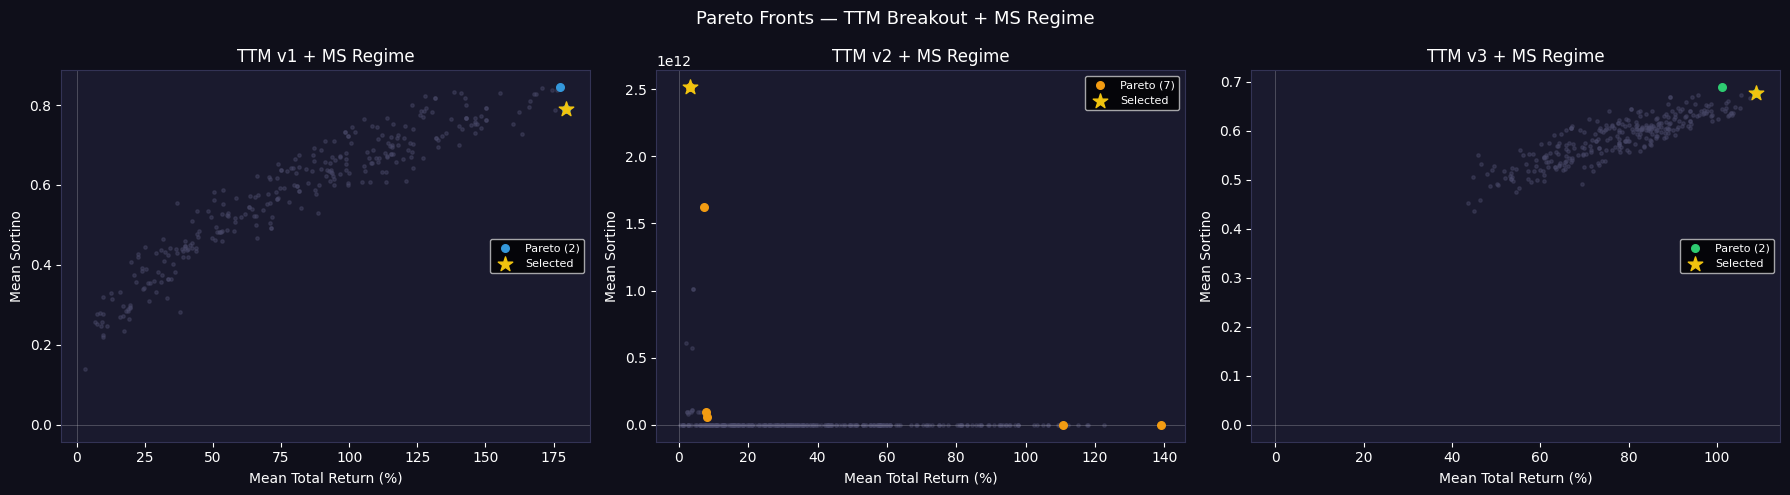

In [10]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    study = studies_ms[ver]
    col = COLORS[ver]
    ax.set_facecolor('#1a1a2e')
    all_v = [(t.values[0], t.values[1]) for t in study.trials
             if t.values and t.values[0] != -999.0]
    pf_v = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter([v[0] for v in all_v], [v[1] for v in all_v],
               color='#4a4a6a', s=6, alpha=0.4)
    ax.scatter([v[0] for v in pf_v], [v[1] for v in pf_v],
               color=col, s=30, zorder=5, label=f'Pareto ({len(pf_v)})')
    bx, by = best_trials_ms[ver].values
    ax.scatter([bx], [by], color='#f1c40f', s=120, marker='*', zorder=6, label='Selected')
    ax.axvline(0, color='white', lw=0.5, alpha=0.3)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.set_title(f'TTM {ver} + MS Regime', color='white')
    ax.set_xlabel('Mean Total Return (%)', color='white')
    ax.set_ylabel('Mean Sortino', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

plt.suptitle('Pareto Fronts — TTM Breakout + MS Regime', color='white', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Final Backtest — Optimised v1 / v2 / v3 + MS Regime


In [11]:
portfolios_ms = {}
regime_results_ms = {}
regime_masks_ms = {}

for ver in ['v1', 'v2', 'v3']:
    p = best_params_ms[ver]
    print(f'Running optimised {ver} + MS ...')
    entries = compute_signals(
        close, high, low,
        bb_window                 = p['bb_window'],
        bb_multiplier             = p['bb_multiplier'],
        bb_matype                 = 0,
        kc_window                 = p['kc_window'],
        kc_multiplier             = p['kc_multiplier'],
        kc_atr_period             = p['kc_atr_period'],
        donichan_window           = p['donichan_window'],
        osc_smoothing_period      = p['osc_smoothing_period'],
        entry_version             = ver,
        consecutive_neg_threshold = p.get('consecutive_neg_threshold', 7),
        william_vix_period        = p.get('william_vix_period', 20),
        use_kama_slope            = True,
        kama_period               = p.get('kama_period', 10),
        kama_fast                 = p.get('kama_fast', 2),
        kama_slow                 = p.get('kama_slow', 30),
        kama_slope_win            = p.get('kama_slope_win', 5),
        flat_threshold_pct        = p.get('flat_threshold_pct', 1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier    = p['atr_multiplier'],
        atr_period        = p.get('atr_period', 10),
        low_stop_lookback = p.get('low_stop_lookback', 5),
    )
    ms = FIXED_MS_FILTER['ms']
    high_stress = FIXED_MS_FILTER['high_stress']
    switch_down = FIXED_MS_FILTER['switch_down']
    switch_up = FIXED_MS_FILTER['switch_up']
    entries = entries & high_stress
    exits = exits.vbt | switch_down.vbt

    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios_ms[ver] = pf
    regime_results_ms[ver] = ms
    regime_masks_ms[ver] = {
        'high_stress': high_stress,
        'switch_down': switch_down,
        'switch_up': switch_up,
    }
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('\nAll done.')


Running optimised v1 + MS ...
  signals=55,711  trades=17,066
Running optimised v2 + MS ...
  signals=818  trades=473
Running optimised v3 + MS ...
  signals=10,556  trades=8,542

All done.


## 10. Comparison — Stats Table


In [12]:
def version_stats(label, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    cm = pf.calmar_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    tr = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
    mdd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna()
    wr = pf.trades.win_rate().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Strategy': label,
        'Sharpe mean': round(s.mean(), 3),
        'Sharpe median': round(s.median(), 3),
        'Sharpe > 0': f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1': f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean': round(so.mean(), 3),
        'Calmar mean': round(cm.mean(), 3),
        'Total Ret mean': f'{tr.mean() * 100:.1f}%',
        'Max DD mean': f'{mdd.mean() * 100:.1f}%',
        'Win Rate mean': f'{wr.mean() * 100:.1f}%',
        'Trades median': int(pf.trades.count().median()),
    }


rows = [
    version_stats('Baseline (no filter)', pf_base),
    version_stats('Baseline + MS gate', pf_base_ms),
] + [
    version_stats(f'Opt {ver} + MS', portfolios_ms[ver])
    for ver in ['v1', 'v2', 'v3']
]
stats_df = pd.DataFrame(rows).set_index('Strategy').T
stats_df


Strategy,Baseline (no filter),Baseline + MS gate,Opt v1 + MS,Opt v2 + MS,Opt v3 + MS
Sharpe mean,0.596,0.462,0.48,0.039,0.425
Sharpe median,0.581,0.462,0.473,0.084,0.42
Sharpe > 0,187/197,180/197,171/197,95/170,168/197
Sharpe > 1,26/197,12/197,23/197,1/170,10/197
Sortino mean,0.938,0.738,0.789,2514004935532.275879,0.676
Calmar mean,0.381,0.282,0.322,1164422218618.068115,0.258
Total Ret mean,223.7%,113.3%,179.5%,3.3%,108.9%
Max DD mean,-43.9%,-38.6%,-37.8%,-6.0%,-39.2%
Win Rate mean,35.6%,39.3%,41.8%,46.4%,44.2%
Trades median,59,30,89,2,45


## 11. Sharpe Distribution — Regime Filter vs No Filter


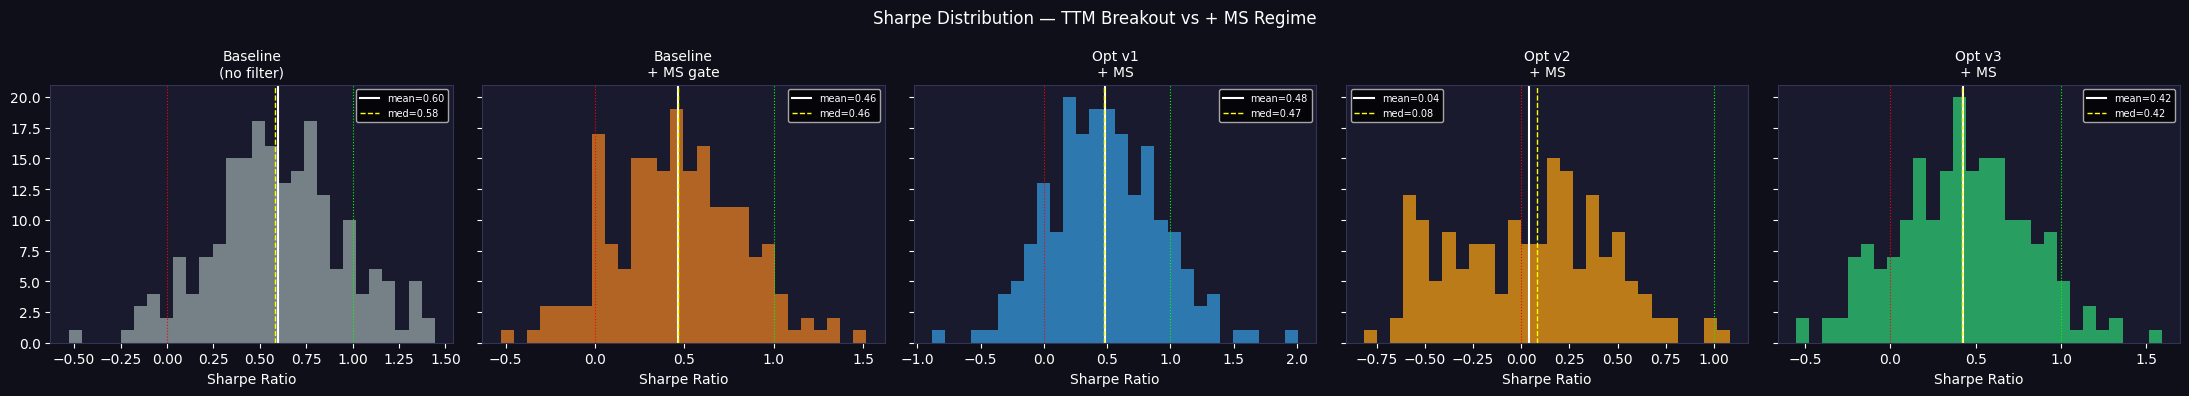

In [13]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

entries_list = [
    ('Baseline\n(no filter)', pf_base, '#95a5a6'),
    ('Baseline\n+ MS gate', pf_base_ms, '#e67e22'),
] + [(f'Opt {ver}\n+ MS', portfolios_ms[ver], COLORS[ver]) for ver in ['v1', 'v2', 'v3']]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(), color='white', lw=1.5, ls='-', label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.8, ls=':')
    ax.axvline(1, color='lime', lw=0.8, ls=':')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

plt.suptitle('Sharpe Distribution — TTM Breakout vs + MS Regime', color='white', fontsize=12)
plt.tight_layout()
plt.show()


## 12. Delta Sharpe vs Baseline (No Filter)


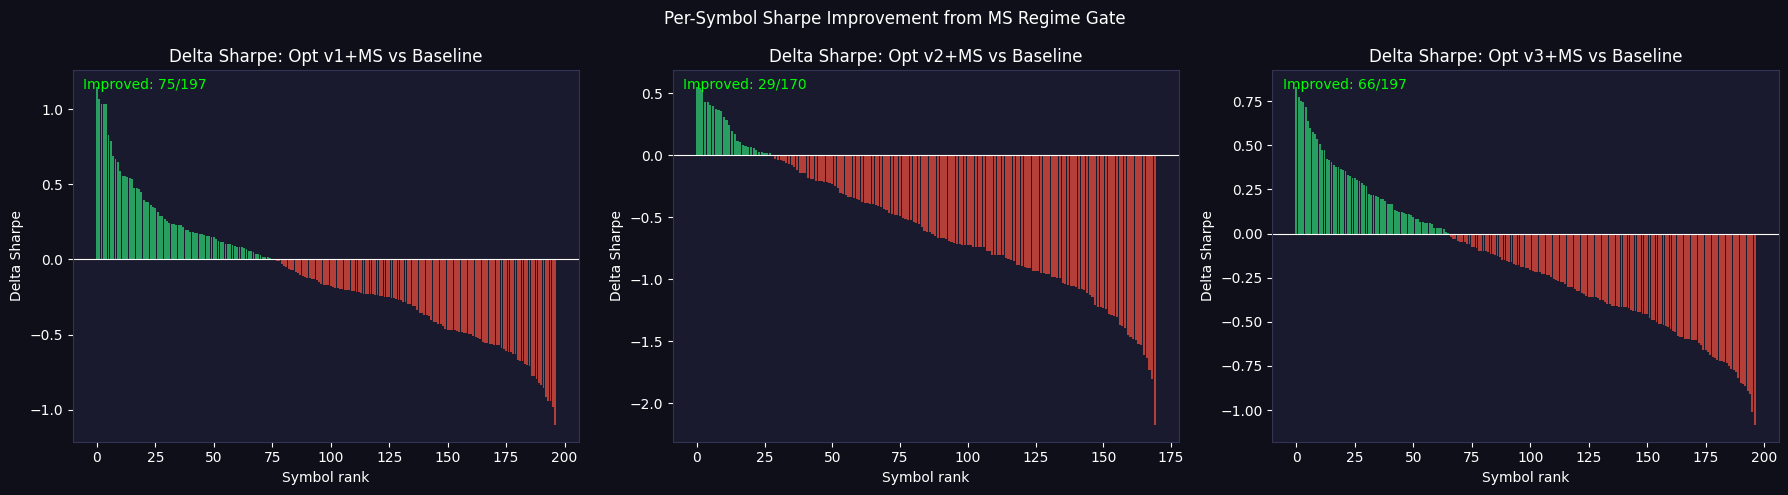

In [14]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

sr_base = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan)

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    pf = portfolios_ms[ver]
    sr_opt = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    delta = (sr_opt - sr_base).dropna().sort_values(ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta]
    ax.set_facecolor('#1a1a2e')
    ax.bar(range(len(delta)), delta.values, color=colors, alpha=0.75)
    ax.axhline(0, color='white', lw=0.8)
    ax.set_title(f'Delta Sharpe: Opt {ver}+MS vs Baseline', color='white')
    ax.set_xlabel('Symbol rank', color='white')
    ax.set_ylabel('Delta Sharpe', color='white')
    ax.tick_params(colors='white')
    improved = (delta > 0).sum()
    ax.text(0.02, 0.95, f'Improved: {improved}/{len(delta)}',
            transform=ax.transAxes, color='lime', fontsize=10)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

plt.suptitle('Per-Symbol Sharpe Improvement from MS Regime Gate', color='white', fontsize=12)
plt.tight_layout()
plt.show()


## 13. Single-Symbol — TTM Entries with MS Regime Overlay


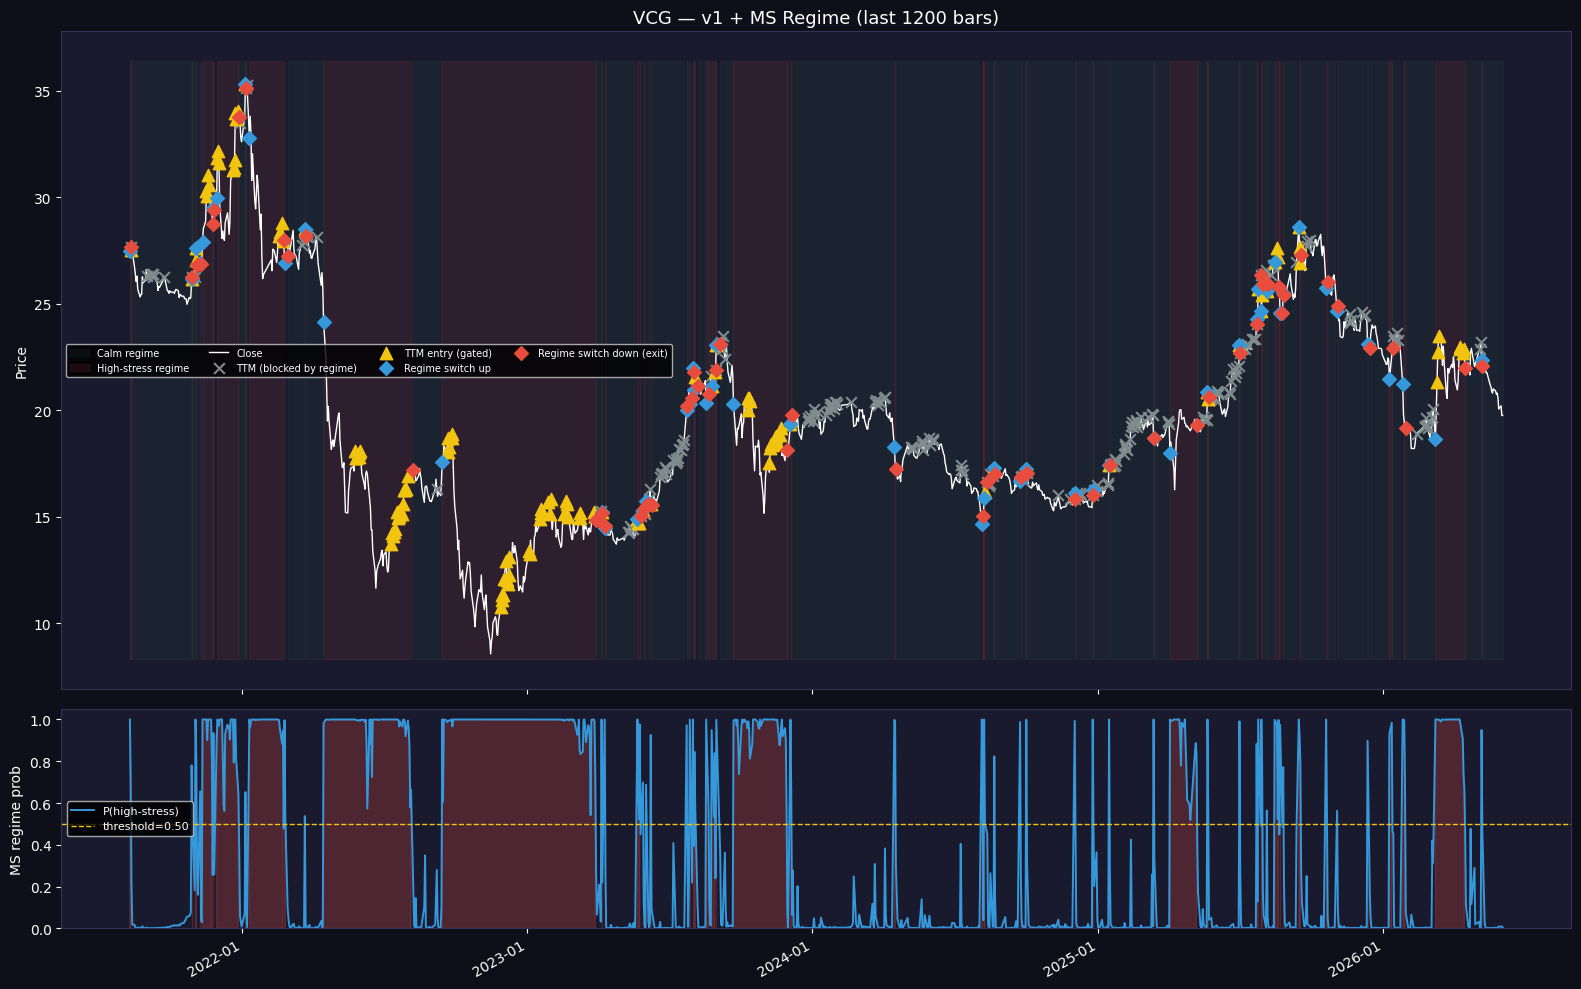

VCG | Sharpe: 0.275  Total Ret: 28.1%


In [15]:
VER = 'v1'
SYMBOL = 'VCG'
LOOKBACK_DAYS = 1200

p = best_params_ms[VER]
ms_s = regime_results_ms[VER]
mask_s = regime_masks_ms[VER]

high_stress = mask_s['high_stress'][SYMBOL].values.astype(bool)
switch_up = mask_s['switch_up'][SYMBOL].values.astype(bool)
switch_dn = mask_s['switch_down'][SYMBOL].values.astype(bool)
regime_prob = ms_s['regime_prob'][SYMBOL].values

ttm_entries_raw = compute_signals(
    close, high, low,
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'], bb_matype=0,
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
    kc_atr_period=p['kc_atr_period'],
    donichan_window=p['donichan_window'], osc_smoothing_period=p['osc_smoothing_period'],
    entry_version=VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
    william_vix_period=p.get('william_vix_period', 20),
    use_kama_slope=True,
    kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
    kama_slow=p.get('kama_slow', 30), kama_slope_win=p.get('kama_slope_win', 5),
    flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
)[SYMBOL].values.astype(bool)
ttm_gated = ttm_entries_raw & high_stress

c_sym = close[SYMBOL].values
dates = close.index
n_show = min(LOOKBACK_DAYS, len(dates))
sl_ = slice(-n_show, None)
dates_s = dates[sl_]

def s(arr):
    return arr[sl_]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
price_s = s(c_sym)
ymin = np.nanmin(price_s) * 0.97
ymax = np.nanmax(price_s) * 1.03
ax.fill_between(dates_s, ymin, ymax, where=~s(high_stress),
                color='#2ecc71', alpha=0.05, label='Calm regime')
ax.fill_between(dates_s, ymin, ymax, where=s(high_stress),
                color='#e74c3c', alpha=0.10, label='High-stress regime')
ax.plot(dates_s, price_s, color='white', lw=1.0, label='Close')

blocked = s(ttm_entries_raw) & ~s(ttm_gated)
ax.scatter(dates_s[blocked], price_s[blocked],
           marker='x', color='#7f8c8d', s=60, zorder=4, label='TTM (blocked by regime)')
ax.scatter(dates_s[s(ttm_gated)], price_s[s(ttm_gated)],
           marker='^', color='#f1c40f', s=80, zorder=5, label='TTM entry (gated)')
ax.scatter(dates_s[s(switch_up)], price_s[s(switch_up)],
           marker='D', color='#3498db', s=50, zorder=6, label='Regime switch up')
ax.scatter(dates_s[s(switch_dn)], price_s[s(switch_dn)],
           marker='D', color='#e74c3c', s=50, zorder=6, label='Regime switch down (exit)')
ax.set_title(f'{SYMBOL} — {VER} + MS Regime (last {n_show} bars)', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=7, ncol=4)
ax.tick_params(colors='white')
for sp in ax.spines.values():
    sp.set_edgecolor('#333355')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.plot(dates_s, s(regime_prob), color='#3498db', lw=1.4, label='P(high-stress)')
ax2.fill_between(dates_s, 0, s(regime_prob), where=s(high_stress), color='#e74c3c', alpha=0.25)
ax2.axhline(MS_PROB_THRESHOLD, color='#f1c40f', lw=1.0, ls='--',
            label=f"threshold={MS_PROB_THRESHOLD:.2f}")
ax2.set_ylabel('MS regime prob', color='white')
ax2.set_ylim(0, 1.05)
ax2.tick_params(colors='white')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax2.spines.values():
    sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()
pf_sym = portfolios_ms[VER]
print(f'{SYMBOL} | Sharpe: {pf_sym.sharpe_ratio()[SYMBOL]:.3f}  Total Ret: {pf_sym.total_return()[SYMBOL] * 100:.1f}%')


## 14. Save Results


In [16]:
h5_file = '../backend/assets/backtest_results_006_ms_regime.h5'

with pd.HDFStore(h5_file, mode='w') as store:
    for ver in ['v1', 'v2', 'v3']:
        study = studies_ms[ver]
        rows = []
        for t in study.best_trials:
            row = {'trial': t.number, 'total_return': t.values[0], 'sortino': t.values[1]}
            row.update(t.params)
            rows.append(row)
        store.put(f'pareto_{ver}', pd.DataFrame(rows), format='table')
        store.put(f'best_params_{ver}', pd.DataFrame([best_params_ms[ver]]), format='table')
        sr = portfolios_ms[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
        store.put(f'sharpe_{ver}', sr, format='table')

print(f'Saved to {h5_file}')


TypeError: MultiIndex not supported here!